In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Ridge



In [4]:
##generamos datos de entrenamiento unidimensionales
def gen_data(m, seed=1, scale=0.7):
   """ generate a data set based on a x^2 with added noise """
   c = 0
   x_train = np.linspace(0, 49, m)
   np.random.seed(seed)
   y_ideal = x_train**2 + c
   y_train = y_ideal + scale * y_ideal*(np.random.sample((m,))-0.5)
   x_ideal = x_train
   return x_train, y_train, x_ideal, y_ideal

Error de entrenamiento: 11855.04797632714
Error de prueba: 48579.46832193767


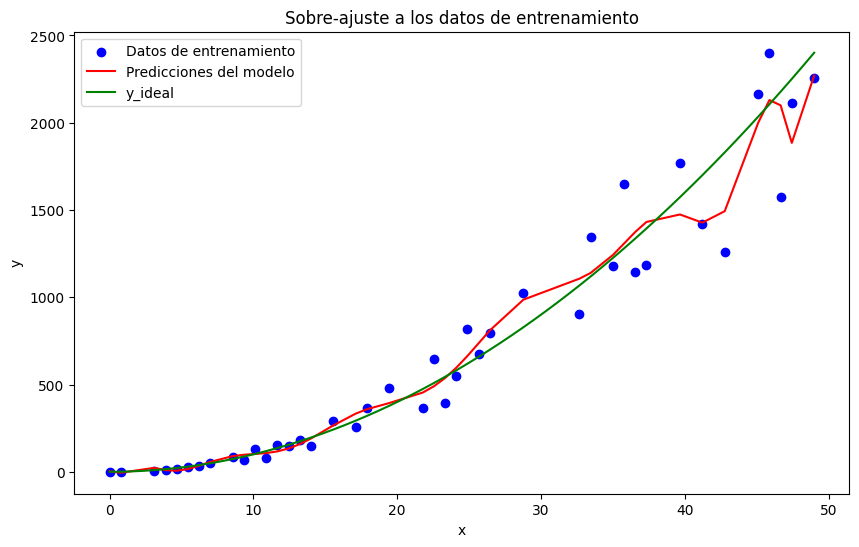

In [78]:
#SOBREAJUSTE A LOS EJEMPLOS DE ENTRENAMIENTO
#Generar datos de entrenamiento
x_train, y_train, x_ideal, y_ideal = gen_data(64)

#Dividir datos en conjuntos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.33, random_state=1)

#Transformar datos de entrenamiento
poly_features = PolynomialFeatures(degree=15, include_bias=False)
#La funcion fit_transform de polynomialfeatures necesita un array bidimensional de entrada
x_train_reshape = x_train[:,None]
x_poly_train = poly_features.fit_transform(x_train_reshape)

#Normalizar datos de entrenamiento
scaler = StandardScaler()
x_poly_train_scaled = scaler.fit_transform(x_poly_train)

#Instanciar y entrenar modelo de regresión lineal
model = LinearRegression()
model.fit(x_poly_train_scaled, y_train)

# Generar predicciones para datos de entrenamiento y prueba
y_train_pred = model.predict(x_poly_train_scaled)
x_test_reshape = x_test[:,None]
x_poly_test = poly_features.transform(x_test_reshape)
x_poly_test_scaled = scaler.transform(x_poly_test)
y_test_pred = model.predict(x_poly_test_scaled)

##calcular el error
error_train = 1 / (2 * len(y_train)) * np.sum((model.predict(x_poly_train_scaled) - y_train) ** 2)
error_test = 1 / (2 * len(y_test)) * np.sum((model.predict(x_poly_test_scaled) - y_test) ** 2)

print("Error de entrenamiento:", error_train)
print("Error de prueba:", error_test)


#Es necesario ordenar  los datos de entrenamiento y las predicciones
#del modelo segun los valores de x_train para que sigan un patron en la grafica
sorted_indices = np.argsort(x_train)
x_train_sorted = x_train[sorted_indices]
y_train_sorted = y_train[sorted_indices]
y_train_pred_sorted = y_train_pred[sorted_indices]

#Dibujar ajuste del modelo a los datos de entrenamiento
plt.figure(figsize=(10, 6))
plt.scatter(x_train_sorted, y_train_sorted, color='blue', label='Datos de entrenamiento')
plt.plot(x_train_sorted, y_train_pred_sorted, color='red', label='Predicciones del modelo')
plt.plot(x_ideal, y_ideal, color='green', label='y_ideal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sobre-ajuste a los datos de entrenamiento')
plt.legend()
plt.show()



Mejor grado del polinomio: 2
Error de validación mínimo: 14526.232808841509
Error de prueba del modelo final: 31451.50964532579


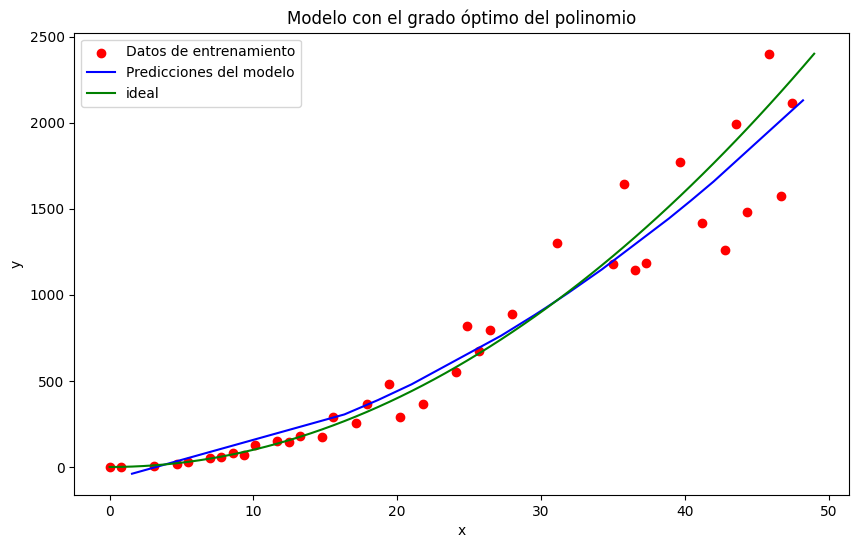

In [85]:
# ELECCIÓN DEL GRADO DEL POLINOMIO USANDO UN CONJUNTO DE VALIDACIÓN
#Generar datos de entrenamiento, validación y prueba
x_train_val, y_train_val, x_ideal, y_ideal = gen_data(64)
x_train_val, x_test, y_train_val, y_test = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=1)
#60% para entrenamiento, 20% para validación, 20% para prueba
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=1)

#Inicializar variables para el mejor grado y menor error de validación
best_degree = None
min_val_error = float('inf')

#Probar diferentes grados del polinomio
for degree in range(1, 11):
    #Transformar datos de entrenamiento y validación
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    x_train_reshape = x_train[:,None]
    x_poly_train = poly_features.fit_transform(x_train_reshape)
    x_val_reshape = x_val[:,None]
    x_poly_val = poly_features.transform(x_val_reshape)

    #Normalizar datos de entrenamiento y validación
    scaler = StandardScaler()
    x_poly_train_scaled = scaler.fit_transform(x_poly_train)
    x_poly_val_scaled = scaler.transform(x_poly_val)

    #Entrenar modelo de regresión lineal
    model = LinearRegression()
    model.fit(x_poly_train_scaled, y_train)

    #Evaluar modelo sobre datos de validación
    y_val_pred = model.predict(x_poly_val_scaled)
    val_error = 1 / (2 * len(y_val)) * np.sum((y_val_pred - y_val) ** 2)

    #Actualizar el mejor grado y menor error de validación
    if val_error < min_val_error:
        best_degree = degree
        min_val_error = val_error

print("Mejor grado del polinomio:", best_degree)
print("Error de validación mínimo:", min_val_error)


#Entrenar modelo final con el mejor grado del polinomio utilizando todos los datos de entrenamiento
poly_features = PolynomialFeatures(degree=best_degree, include_bias=False)
x_train_val_reshape = x_train_val[:,None]
x_poly_train_val = poly_features.fit_transform(x_train_val_reshape)
x_test_reshape = x_test[:,None]
x_poly_test = poly_features.transform(x_test_reshape)
scaler = StandardScaler()
x_poly_train_val_scaled = scaler.fit_transform(x_poly_train_val)
x_poly_test_scaled = scaler.transform(x_poly_test)
model_final = LinearRegression()
model_final.fit(x_poly_train_val_scaled, y_train_val)

#Evaluar modelo final sobre datos de prueba
y_test_pred = model_final.predict(x_poly_test_scaled)
test_error = 1 / (2 * len(y_test)) * np.sum((y_test_pred - y_test) ** 2)

print("Error de prueba del modelo final:", test_error)

#Es necesario ordenar  los datos de entrenamiento y las predicciones
#del modelo segun los valores de x_train para que sigan un patron en la grafica
sorted_indices_train = np.argsort(x_train)
x_train_sorted = x_train[sorted_indices_train]
y_train_sorted = y_train[sorted_indices_train]
sorted_indices_test = np.argsort(x_test)
x_test_sorted = x_test[sorted_indices_test]
y_test_pred_sorted = y_test_pred[sorted_indices_test]

#Predicciones del modelo con menor error
plt.figure(figsize=(10, 6))
plt.scatter(x_train_sorted, y_train_sorted, color='red', label='Datos de entrenamiento')
plt.plot(x_test_sorted, y_test_pred_sorted, color='blue', label='Predicciones del modelo')
plt.plot(x_ideal, y_ideal, color='green', label='ideal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Modelo con el grado óptimo del polinomio')
plt.legend()
plt.show()


Mejor valor de lambda: 600.0
Error de prueba del modelo final: 56989.8961210782


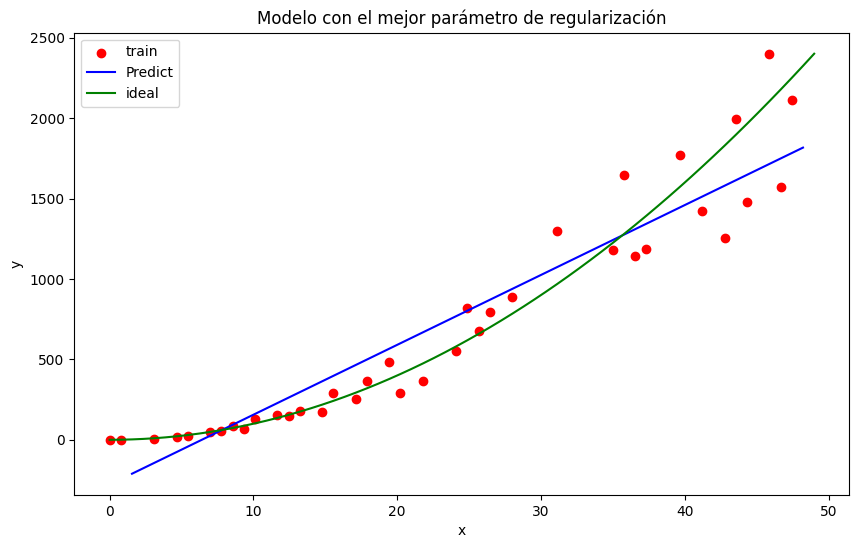

In [86]:
##ELECCIÓN DEL PARAMETRO LAMBDA
#Generar datos de entrenamiento, validación y prueba
x_train_val, y_train_val, x_ideal, y_ideal = gen_data(64)
x_train_val, x_test, y_train_val, y_test = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=1)
#60% para entrenamiento, 20% para validación, 20% para prueba
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.25, random_state=1)

#Definir valores de lambda a probar
alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 300, 600, 900]

#Entrenar modelo Ridge con validación cruzada para seleccionar el mejor lambda
ridge_cv = RidgeCV(alphas=alphas, cv=5)
x_train_val_reshape = x_train_val[:,None]
ridge_cv.fit(x_train_val_reshape, y_train_val)

#Obtener el mejor valor de lambda
best_alpha = ridge_cv.alpha_
print("Mejor valor de lambda:", best_alpha)

#Entrenar modelo final con el mejor lambda utilizando todos los datos de entrenamiento
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(x_train_val_reshape, y_train_val)

#Evaluar modelo final sobre datos de prueba
x_test_reshape = x_test[:,None]
predicts = ridge_final.predict(x_test_reshape)
test_error = 1 / (2 * len(y_test)) * np.sum((predicts - y_test) ** 2)
print("Error de prueba del modelo final:", test_error)

sorted_indices_train = np.argsort(x_train)
x_train_sorted = x_train[sorted_indices_train]
y_train_sorted = y_train[sorted_indices_train]
sorted_indices_test = np.argsort(x_test)
x_test_sorted = x_test[sorted_indices_test]
predicts_sorted = predicts[sorted_indices_test]

#Predicciones del modelo con mejor valor lambda
plt.figure(figsize=(10, 6))
plt.scatter(x_train_sorted, y_train_sorted, color='red', label='train')
plt.plot(x_test_sorted, predicts_sorted, color='blue', label='Predict')
plt.plot(x_ideal, y_ideal, color='green', label='ideal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Modelo con el mejor parámetro de regularización')
plt.legend()
plt.show()



Mejor grado del polinomio: 2
Mejor valor de lambda: 1
Error de prueba del modelo final: 25662.818203559775


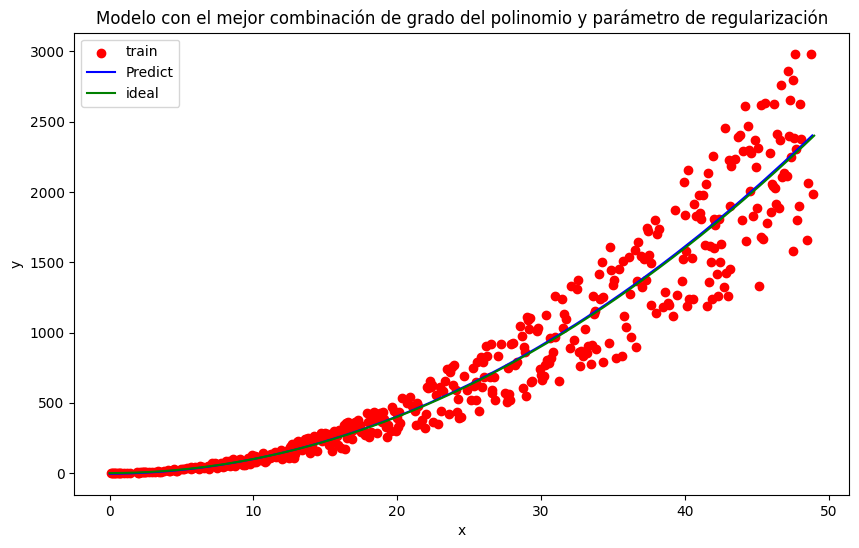

In [87]:
##ELECCIÓN DE HIPER-PARÁMETROS
#Generar datos de entrenamiento, validación y prueba
x_train_val_test, y_train_val_test, x_ideal, y_ideal= gen_data(750)
x_train_val_test = x_train_val_test[:,None]
#60% para entrenamiento, 20% para validación, 20% para prueba
x_train_val_test, x_test, y_train_val_test, y_test = train_test_split(x_train_val_test, y_train_val_test, test_size=0.2, random_state=1)
x_train, x_val, y_train, y_val = train_test_split(x_train_val_test, y_train_val_test, test_size=0.25, random_state=1)

#Definir grados del polinomio y valores de lambda a probar
degrees = np.arange(1, 16)
alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 300, 600, 900]
best_error = float('inf')
best_degree = None
best_alpha = None

#Búsqueda exhaustiva de la mejor combinación de grado del polinomio y valor de lambda
for degree in degrees:
    for alpha in alphas:
        #Aplicar transformaciones polinomiales y normalizar datos
        poly_features = PolynomialFeatures(degree=degree, include_bias=False)
        x_train_poly = poly_features.fit_transform(x_train)
        x_val_poly = poly_features.transform(x_val)

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train_poly)
        x_val_scaled = scaler.transform(x_val_poly)

        #Entrenar modelo Ridge con validación cruzada
        ridge_cv = RidgeCV(alphas=[alpha], cv=5)
        ridge_cv.fit(x_train_scaled, y_train)

        #Evaluar modelo
        val_error = 1 / (2 * len(y_val)) * np.sum((ridge_cv.predict(x_val_scaled) - y_val) ** 2)

        #Actualizar mejores parámetros si es necesario
        if val_error < best_error:
            best_error = val_error
            best_degree = degree
            best_alpha = alpha

#Entrenar modelo final con la mejor combinación de grado del polinomio y valor de lambda
poly_features = PolynomialFeatures(degree=best_degree, include_bias=False)
x_train_poly = poly_features.fit_transform(x_train_val_test)
x_test_poly = poly_features.transform(x_test)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_poly)
x_test_scaled = scaler.transform(x_test_poly)

ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(x_train_scaled, y_train_val_test)

#Evaluar modelo final sobre datos de prueba
predicts = ridge_final.predict(x_test_scaled)
test_error = 1 / (2 * len(y_test)) * np.sum((predicts - y_test) ** 2)
print("Mejor grado del polinomio:", best_degree)
print("Mejor valor de lambda:", best_alpha)
print("Error de prueba del modelo final:", test_error)

sorted_indices_train = np.argsort(x_train.flatten())
x_train_sorted = x_train[sorted_indices_train]
y_train_sorted = y_train[sorted_indices_train]
sorted_indices_test = np.argsort(x_test.flatten())
x_test_sorted = x_test[sorted_indices_test]
predicts_sorted = predicts[sorted_indices_test]


#Predicciones del modelo con mejor valor lambda
plt.figure(figsize=(10, 6))
plt.scatter(x_train_sorted, y_train_sorted, color='red', label='train')
plt.plot(x_test_sorted, predicts_sorted, color='blue', label='Predict')
plt.plot(x_ideal, y_ideal, color='green', label='ideal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Modelo con el mejor combinación de grado del polinomio y parámetro de regularización')
plt.legend()
plt.show()


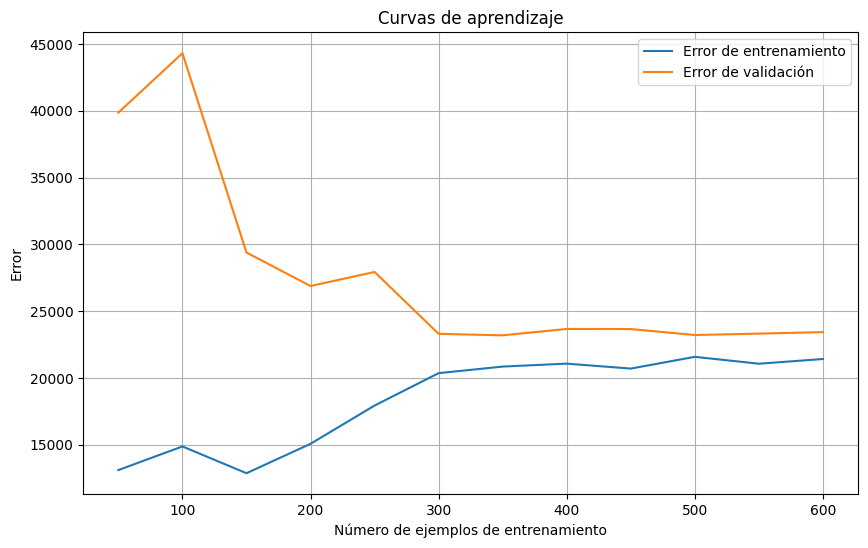

In [34]:
##CURVAS DE APRENDIZAJE
#Generar datos de entrenamiento y validación
x_train_val, y_train_val, _, _ = gen_data(1000)
x_train_val = x_train_val[:,None]
#60% para entrenamiento, 40% para validación
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.4, random_state=1)

train_errors = []
val_errors = []

#Entrenar modelo con polinomios de grado 16 sin regularizar con diferentes tamaños de conjunto de entrenamiento
for size in range(50, 601, 50):
    #Seleccionar subconjunto de entrenamiento
    x_train_subset = x_train[:size]
    y_train_subset = y_train[:size]

    #Aplicar transformaciones polinomiales y normalizar datos
    poly_features = PolynomialFeatures(degree=16, include_bias=False)
    x_train_poly = poly_features.fit_transform(x_train_subset)
    x_val_poly = poly_features.transform(x_val)

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_poly)
    x_val_scaled = scaler.transform(x_val_poly)

    #Entrenar modelo sin regularizar
    model = Ridge(alpha=0)
    model.fit(x_train_scaled, y_train_subset)

    #Calcular errores de entrenamiento y validación utilizando la función J(w, b)
    error_train = 1 / (2 * len(y_train_subset)) * np.sum((model.predict(x_train_scaled) - y_train_subset) ** 2)
    error_val = 1 / (2 * len(y_val)) * np.sum((model.predict(x_val_scaled) - y_val) ** 2)

    #Guardar errores en listas
    train_errors.append(error_train)
    val_errors.append(error_val)

#Dibujar curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(50, 601, 50), train_errors, label='Error de entrenamiento')
plt.plot(range(50, 601, 50), val_errors, label='Error de validación')
plt.title('Curvas de aprendizaje')
plt.xlabel('Número de ejemplos de entrenamiento')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()
